# Planar 3SAT To Square-Grid-Aligned 3SAT

This notebook searches for a rectilinear drawing from only a planar 3SAT
instance. It does not assume monotonicity, a variable order, or a top/bottom
clause partition.

In [123]:
from dataclasses import dataclass
from itertools import permutations
from pathlib import Path

import networkx as nx
from pysat.formula import CNF

In [124]:
@dataclass(frozen=True)
class Clause:
    label: int
    literals: tuple[int, ...]

    @property
    def variables(self) -> tuple[int, ...]:
        return tuple(abs(literal) for literal in self.literals)


@dataclass(frozen=True)
class ClauseInterval:
    label: int
    left: int
    right: int


@dataclass(frozen=True)
class RectilinearPartition:
    variable_order: tuple[int, ...]
    clause_side: dict[int, str]
    conflict_graph: nx.Graph


def label_str(label: int) -> str:
    return "C" + str(label)

In [125]:
def clauses_from_formula(formula: CNF) -> tuple[Clause, ...]:
    clauses: list[Clause] = []

    for label, raw_clause in enumerate(formula.clauses, start=1):
        if not (1 <= len(raw_clause) <= 3):
            raise ValueError(
                f"{label_str(label)} must contain between 1 and 3 literals."
            )

        if any(literal == 0 for literal in raw_clause):
            raise ValueError(f"{label_str(label)} contains literal 0.")

        clauses.append(Clause(label=label, literals=tuple(raw_clause)))

    return tuple(clauses)


def variables_from_clauses(clauses: tuple[Clause, ...]) -> tuple[int, ...]:
    return tuple(sorted({variable for clause in clauses for variable in clause.variables}))

In [126]:
def build_incidence_graph(formula: CNF) -> nx.Graph:
    G = nx.Graph()

    for clause in clauses_from_formula(formula):
        clause_node = label_str(clause.label)
        G.add_node(clause_node, kind="clause", label=clause.label)

        for literal in clause.literals:
            variable = abs(literal)
            variable_node = f"x{variable}"
            G.add_node(variable_node, kind="variable", variable=variable)

            if G.has_edge(variable_node, clause_node):
                G[variable_node][clause_node]["literals"].append(literal)
            else:
                G.add_edge(variable_node, clause_node, literals=[literal])

    return G


def validate_planar_formula(formula: CNF) -> tuple[nx.Graph, nx.PlanarEmbedding]:
    G = build_incidence_graph(formula)
    is_planar, embedding = nx.check_planarity(G)

    if not is_planar:
        raise ValueError("The incidence graph is not planar.")

    return G, embedding

In [127]:
def embedding_rotation_system(embedding: nx.PlanarEmbedding) -> dict[str, list[str]]:
    return {
        node: list(embedding.neighbors_cw_order(node))
        for node in sorted(embedding.nodes(), key=str)
    }


def embedding_faces(embedding: nx.PlanarEmbedding) -> list[list[str]]:
    visited = set()
    faces = []

    for node in embedding.nodes():
        for neighbor in embedding.neighbors_cw_order(node):
            if (node, neighbor) in visited:
                continue

            face = embedding.traverse_face(node, neighbor)
            faces.append(face)

            for index, face_node in enumerate(face):
                next_node = face[(index + 1) % len(face)]
                visited.add((face_node, next_node))

    return faces


def summarize_embedding(
    graph: nx.Graph,
    embedding: nx.PlanarEmbedding,
) -> None:
    print(
        f"Incidence graph: {graph.number_of_nodes()} nodes, "
        f"{graph.number_of_edges()} edges"
    )

    print("\nRotation system, clockwise neighbors at each node:")
    for node, neighbors in embedding_rotation_system(embedding).items():
        print(f"  {node}: {neighbors}")

    print("\nFaces:")
    for index, face in enumerate(embedding_faces(embedding), start=1):
        print(f"  F{index}: {face}")

In [128]:
def clause_interval(clause: Clause, variable_position: dict[int, int]) -> ClauseInterval:
    xs = [variable_position[variable] for variable in clause.variables]
    return ClauseInterval(label=clause.label, left=min(xs), right=max(xs))


def intervals_interleave(a: ClauseInterval, b: ClauseInterval) -> bool:
    return (
        a.left < b.left < a.right < b.right
        or b.left < a.left < b.right < a.right
    )


def build_conflict_graph(
    clauses: tuple[Clause, ...],
    variable_order: tuple[int, ...],
) -> nx.Graph:
    variable_position = {
        variable: index
        for index, variable in enumerate(variable_order)
    }
    intervals = {
        clause.label: clause_interval(clause, variable_position)
        for clause in clauses
    }

    graph = nx.Graph()
    graph.add_nodes_from(clause.label for clause in clauses)

    for i, a in enumerate(clauses):
        for b in clauses[i + 1:]:
            if intervals_interleave(intervals[a.label], intervals[b.label]):
                graph.add_edge(a.label, b.label)

    return graph

In [129]:
def side_partitions_for_order(
    clauses: tuple[Clause, ...],
    variable_order: tuple[int, ...],
):
    conflict_graph = build_conflict_graph(clauses, variable_order)

    if not nx.is_bipartite(conflict_graph):
        return

    colors = nx.bipartite.color(conflict_graph)
    components = [
        sorted(component)
        for component in nx.connected_components(conflict_graph)
    ]

    for flip_mask in range(2 ** len(components)):
        clause_side = {}

        for component_index, component in enumerate(components):
            flip = (flip_mask >> component_index) & 1

            for label in component:
                color = colors[label] ^ flip
                clause_side[label] = "top" if color == 0 else "bottom"

        yield RectilinearPartition(
            variable_order=variable_order,
            clause_side=clause_side,
            conflict_graph=conflict_graph,
        )


def find_rectilinear_partition(
    formula: CNF,
    max_variables: int = 8,
) -> RectilinearPartition:
    validate_planar_formula(formula)

    clauses = clauses_from_formula(formula)
    variables = variables_from_clauses(clauses)

    if len(variables) > max_variables:
        raise ValueError(
            "This prototype searches all variable orders. "
            f"Got {len(variables)} variables, but max_variables={max_variables}."
        )

    for variable_order in permutations(variables):
        # Reversing the whole spine gives the same drawing, so skip one twin.
        if variable_order[0] > variable_order[-1]:
            continue

        for partition in side_partitions_for_order(clauses, variable_order):
            if partition_has_valid_levels(partition, clauses):
                return partition

    raise ValueError(
        "No variable order produced a two-sided rectilinear interval drawing."
    )

In [130]:
def find_variable_cycle_embedding(
    formula: CNF,
    max_variables: int = 8,
) -> tuple[bool, tuple[int, ...] | None, nx.PlanarEmbedding | None]:
    graph, _embedding = validate_planar_formula(formula)
    variables = variables_from_clauses(clauses_from_formula(formula))

    if len(variables) > max_variables:
        raise ValueError(
            "This prototype searches all variable cycles. "
            f"Got {len(variables)} variables, but max_variables={max_variables}."
        )

    for variable_order in permutations(variables):
        # Reversing a cycle gives the same cyclic order.
        if variable_order[0] > variable_order[-1]:
            continue

        augmented = graph.copy()
        for left, right in zip(variable_order, variable_order[1:] + variable_order[:1]):
            augmented.add_edge(
                f"x{left}",
                f"x{right}",
                kind="variable_cycle",
            )

        is_planar, embedding = nx.check_planarity(augmented)
        if is_planar:
            return True, variable_order, embedding

    return False, None, None

In [131]:
@dataclass(frozen=True)
class Point:
    x: int
    y: int


@dataclass(frozen=True)
class UnitSegment:
    start: Point
    end: Point


@dataclass(frozen=True)
class GridEdge:
    segments: tuple[UnitSegment, ...]

    @property
    def start(self) -> Point:
        return self.segments[0].start

    @property
    def end(self) -> Point:
        return self.segments[-1].end


@dataclass(frozen=True)
class ConnectorMetadata:
    clause_label: int
    literal: int
    variable: int
    slot: int

    @property
    def negated(self) -> bool:
        return self.literal < 0


@dataclass(frozen=True)
class ConnectorEdge:
    metadata: ConnectorMetadata
    edge: GridEdge

    @property
    def start(self) -> Point:
        return self.edge.start

    @property
    def end(self) -> Point:
        return self.edge.end


@dataclass(frozen=True)
class VariableSegment:
    var: int
    x_start: int
    x_end: int
    y: int = 0


@dataclass(frozen=True)
class ClauseSegment:
    label: int
    x_start: int
    x_end: int
    y: int
    literals: tuple[int, ...]


@dataclass(frozen=True)
class SGA3SATGraph:
    variables: dict[int, VariableSegment]
    clauses: dict[int, ClauseSegment]
    edges: tuple[ConnectorEdge, ...]
    partition: RectilinearPartition

In [132]:
LEFT = 0
MIDDLE = 1
RIGHT = 2


def _unit_segments_between(start: Point, end: Point) -> tuple[UnitSegment, ...]:
    if start.x != end.x and start.y != end.y:
        raise ValueError("SGA edge segments must be horizontal or vertical.")

    if start == end:
        return ()

    segments: list[UnitSegment] = []

    if start.x == end.x:
        step = 1 if end.y > start.y else -1
        for y in range(start.y, end.y, step):
            segments.append(UnitSegment(Point(start.x, y), Point(start.x, y + step)))
    else:
        step = 1 if end.x > start.x else -1
        for x in range(start.x, end.x, step):
            segments.append(UnitSegment(Point(x, start.y), Point(x + step, start.y)))

    return tuple(segments)

In [133]:
def compute_clause_levels(
    clauses: tuple[Clause, ...],
    variable_order: tuple[int, ...],
) -> dict[int, int]:
    variable_position = {
        variable: index
        for index, variable in enumerate(variable_order)
    }
    intervals = {
        clause.label: clause_interval(clause, variable_position)
        for clause in clauses
    }

    edges: dict[int, set[int]] = {
        clause.label: set()
        for clause in clauses
    }
    indegree: dict[int, int] = {
        clause.label: 0
        for clause in clauses
    }

    for outer in clauses:
        outer_interval = intervals[outer.label]

        for inner in clauses:
            if outer.label == inner.label:
                continue

            has_blocked_connection = any(
                outer_interval.left < variable_position[variable] < outer_interval.right
                for variable in inner.variables
            )

            if not has_blocked_connection:
                continue

            if outer.label not in edges[inner.label]:
                edges[inner.label].add(outer.label)
                indegree[outer.label] += 1

    ready = sorted(label for label, degree in indegree.items() if degree == 0)
    order: list[int] = []

    while ready:
        label = ready.pop(0)
        order.append(label)

        for neighbor in sorted(edges[label]):
            indegree[neighbor] -= 1
            if indegree[neighbor] == 0:
                ready.append(neighbor)
                ready.sort()

    if len(order) != len(clauses):
        cyclic = ", ".join(
            label_str(label)
            for label, degree in sorted(indegree.items())
            if degree > 0
        )
        raise ValueError(f"Clauses cannot be stacked without crossings: {cyclic}")

    return {
        label: level
        for level, label in enumerate(order, start=1)
    }

In [134]:
def partition_has_valid_levels(
    partition: RectilinearPartition,
    clauses: tuple[Clause, ...],
) -> bool:
    top_clauses = tuple(
        clause for clause in clauses
        if partition.clause_side[clause.label] == "top"
    )
    bottom_clauses = tuple(
        clause for clause in clauses
        if partition.clause_side[clause.label] == "bottom"
    )

    try:
        compute_clause_levels(top_clauses, partition.variable_order)
        compute_clause_levels(bottom_clauses, partition.variable_order)
    except ValueError:
        return False

    return True

In [135]:
def _literal_metadata(
    clause: Clause,
    variable_order: tuple[int, ...],
) -> list[ConnectorMetadata]:
    variable_position = {
        variable: index
        for index, variable in enumerate(variable_order)
    }
    sorted_literals = sorted(
        enumerate(clause.literals),
        key=lambda item: (variable_position[abs(item[1])], item[0]),
    )

    result = []
    for sorted_slot, (_original_slot, literal) in enumerate(sorted_literals):
        result.append(
            ConnectorMetadata(
                clause_label=clause.label,
                literal=literal,
                variable=abs(literal),
                slot=sorted_slot,
            )
        )

    return result


def _build_queues(
    clauses: tuple[Clause, ...],
    levels: dict[int, int],
    variable_order: tuple[int, ...],
) -> dict[int, list[ConnectorMetadata]]:
    sorted_clauses = sorted(
        clauses,
        key=lambda clause: (levels[clause.label], clause.label),
    )

    lefty = {variable: [] for variable in variable_order}
    middle = {variable: [] for variable in variable_order}
    righty = {variable: [] for variable in variable_order}

    for clause in sorted_clauses:
        metadata = _literal_metadata(clause, variable_order)

        if len(metadata) == 1:
            middle[metadata[0].variable].append(metadata[0])
            continue

        left = metadata[0]
        right = metadata[-1]
        middles = metadata[1:-1]

        if left.variable == right.variable:
            lefty[left.variable].extend(metadata)
            continue

        righty[left.variable].insert(0, left)

        for item in middles:
            if item.variable == left.variable:
                righty[item.variable].insert(0, item)
            elif item.variable == right.variable:
                lefty[item.variable].append(item)
            else:
                middle[item.variable].append(item)

        lefty[right.variable].append(right)

    return {
        variable: lefty[variable] + middle[variable] + righty[variable]
        for variable in variable_order
    }

In [136]:
def _add_edges_from_queues(
    queues: dict[int, list[ConnectorMetadata]],
    x_start: dict[int, int],
    levels: dict[int, int],
    direction: int,
    connector_xs_by_clause: dict[int, list[int]],
    edges: list[ConnectorEdge],
) -> None:
    for variable, queue in queues.items():
        for idx, metadata in enumerate(queue):
            if metadata.variable != variable:
                raise ValueError(
                    f"Connector for x{metadata.variable} found in x{variable} queue."
                )

            x = x_start[variable] + idx
            y = direction * levels[metadata.clause_label]

            connector_xs_by_clause.setdefault(metadata.clause_label, []).append(x)

            start = Point(x, 0)
            end = Point(x, y)
            edges.append(
                ConnectorEdge(
                    metadata=metadata,
                    edge=GridEdge(segments=_unit_segments_between(start, end)),
                )
            )

In [137]:
def build_sga_graph(
    formula: CNF,
    max_variable_order_search: int = 8,
) -> SGA3SATGraph:
    clauses = clauses_from_formula(formula)
    partition = find_rectilinear_partition(
        formula,
        max_variables=max_variable_order_search,
    )

    top_clauses = tuple(
        clause for clause in clauses
        if partition.clause_side[clause.label] == "top"
    )
    bottom_clauses = tuple(
        clause for clause in clauses
        if partition.clause_side[clause.label] == "bottom"
    )

    top_levels = compute_clause_levels(top_clauses, partition.variable_order)
    bottom_levels = compute_clause_levels(bottom_clauses, partition.variable_order)

    top_queues = _build_queues(top_clauses, top_levels, partition.variable_order)
    bottom_queues = _build_queues(bottom_clauses, bottom_levels, partition.variable_order)

    segment_width = {
        variable: max(
            1,
            len(top_queues.get(variable, [])),
            len(bottom_queues.get(variable, [])),
        )
        for variable in partition.variable_order
    }

    x_start: dict[int, int] = {}
    cursor = 0
    for variable in partition.variable_order:
        x_start[variable] = cursor
        cursor += segment_width[variable] + 1

    variables = {
        variable: VariableSegment(
            var=variable,
            x_start=x_start[variable],
            x_end=x_start[variable] + segment_width[variable] - 1,
        )
        for variable in partition.variable_order
    }

    connector_xs_by_clause: dict[int, list[int]] = {}
    edges: list[ConnectorEdge] = []

    _add_edges_from_queues(
        top_queues,
        x_start,
        top_levels,
        direction=1,
        connector_xs_by_clause=connector_xs_by_clause,
        edges=edges,
    )
    _add_edges_from_queues(
        bottom_queues,
        x_start,
        bottom_levels,
        direction=-1,
        connector_xs_by_clause=connector_xs_by_clause,
        edges=edges,
    )

    clauses_by_label = {clause.label: clause for clause in clauses}
    clause_segments: dict[int, ClauseSegment] = {}

    for label, xs in connector_xs_by_clause.items():
        side = partition.clause_side[label]
        y = top_levels[label] if side == "top" else -bottom_levels[label]
        clause_segments[label] = ClauseSegment(
            label=label,
            x_start=min(xs),
            x_end=max(xs),
            y=y,
            literals=clauses_by_label[label].literals,
        )

    return SGA3SATGraph(
        variables=variables,
        clauses=clause_segments,
        edges=tuple(edges),
        partition=partition,
    )

In [138]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

%matplotlib inline


_BOX_H = 0.36
_VAR_COLOUR = "#222222"
_TOP_COLOUR = "#2166ac"
_BOTTOM_COLOUR = "#b2182b"
_POS_LITERAL_COLOUR = "#1b9e77"
_NEG_LITERAL_COLOUR = "#d95f02"
_GRIDLINE_COLOUR = "#aaaaaa"


def _graph_bounds(graph: SGA3SATGraph) -> tuple[int, int, int, int]:
    points = []

    for variable in graph.variables.values():
        points.extend([
            Point(variable.x_start, variable.y),
            Point(variable.x_end, variable.y),
        ])

    for clause in graph.clauses.values():
        points.extend([
            Point(clause.x_start, clause.y),
            Point(clause.x_end, clause.y),
        ])

    for edge in graph.edges:
        points.extend([edge.start, edge.end])
        for segment in edge.edge.segments:
            points.extend([segment.start, segment.end])

    return (
        min(point.x for point in points),
        max(point.x for point in points),
        min(point.y for point in points),
        max(point.y for point in points),
    )


def _literal_text(literals: tuple[int, ...]) -> str:
    return " OR ".join(
        f"x{literal}" if literal > 0 else f"not x{abs(literal)}"
        for literal in literals
    )


def _incidence_edge_color(literals: list[int]) -> str:
    if all(literal > 0 for literal in literals):
        return _POS_LITERAL_COLOUR
    if all(literal < 0 for literal in literals):
        return _NEG_LITERAL_COLOUR
    return "#7570b3"

In [139]:
def planar_embedding_positions(
    embedding: nx.PlanarEmbedding,
    scale: float = 8.0,
) -> dict[str, tuple[float, float]]:
    raw_positions = nx.planar_layout(embedding, scale=scale)
    return {
        node: (float(position[0]), float(position[1]))
        for node, position in raw_positions.items()
    }


def draw_planar_embedding(
    graph: nx.Graph,
    embedding: nx.PlanarEmbedding,
    print_positions: bool = True,
    scale: float = 8.0
):
    positions = planar_embedding_positions(embedding, scale)
    fig, axis = plt.subplots(figsize=(8, 6))

    for u, v, data in graph.edges(data=True):
        x1, y1 = positions[u]
        x2, y2 = positions[v]
        axis.plot(
            [x1, x2],
            [y1, y2],
            color=_incidence_edge_color(data["literals"]),
            linewidth=1.5,
            alpha=0.85,
            zorder=1,
        )

    for node, data in graph.nodes(data=True):
        x, y = positions[node]

        if data["kind"] == "variable":
            axis.scatter(
                [x],
                [y],
                s=420,
                marker="o",
                facecolor="white",
                edgecolor=_VAR_COLOUR,
                linewidth=1.5,
                zorder=3,
            )
        else:
            axis.scatter(
                [x],
                [y],
                s=360,
                marker="s",
                facecolor="#f7f7f7",
                edgecolor=_VAR_COLOUR,
                linewidth=1.5,
                zorder=3,
            )

        axis.text(
            x,
            y,
            node,
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            zorder=4,
        )

    axis.set_aspect("equal", adjustable="box")
    axis.set_title("Planar Incidence Graph Embedding")
    axis.axis("off")
    fig.tight_layout()

    if print_positions:
        print("Planar embedding positions:")
        for node, (x, y) in sorted(positions.items(), key=lambda item: str(item[0])):
            print(f"  {node}: ({x:.3f}, {y:.3f})")

    return fig, axis, positions

In [140]:
def draw_sga_graph(graph: SGA3SATGraph, output: Path | str | None = None):
    min_x, max_x, min_y, max_y = _graph_bounds(graph)
    fig_width = max(8.0, (max_x - min_x + 1) * 0.6)
    fig_height = max(4.5, (max_y - min_y + 2) * 1.0)
    fig, axis = plt.subplots(figsize=(fig_width, fig_height))

    axis.axhline(0, color="#bbbbbb", linewidth=1.2, zorder=1)

    for variable in graph.variables.values():
        bx = variable.x_start - 0.4
        bw = variable.x_end - variable.x_start + 0.8
        axis.add_patch(
            FancyBboxPatch(
                (bx, variable.y - _BOX_H / 2),
                bw,
                _BOX_H,
                boxstyle="round,pad=0.02",
                linewidth=1.2,
                edgecolor=_VAR_COLOUR,
                facecolor="white",
                zorder=5,
            )
        )
        axis.text(
            bx + bw / 2,
            variable.y,
            f"x{variable.var}",
            ha="center",
            va="center",
            fontsize=9,
            color=_VAR_COLOUR,
            zorder=6,
        )

    for clause in graph.clauses.values():
        color = _TOP_COLOUR if clause.y > 0 else _BOTTOM_COLOUR
        axis.plot(
            [clause.x_start, clause.x_end],
            [clause.y, clause.y],
            color=color,
            linewidth=2.6,
            zorder=3,
        )
        axis.text(
            (clause.x_start + clause.x_end) / 2,
            clause.y + (0.18 if clause.y > 0 else -0.18),
            f"{label_str(clause.label)}: {_literal_text(clause.literals)}",
            ha="center",
            va=("bottom" if clause.y > 0 else "top"),
            fontsize=9,
            color=color,
            fontweight="bold",
        )

    for edge in graph.edges:
        color = (
            _NEG_LITERAL_COLOUR
            if edge.metadata.negated
            else _POS_LITERAL_COLOUR
        )
        for segment in edge.edge.segments:
            axis.plot(
                [segment.start.x, segment.end.x],
                [segment.start.y, segment.end.y],
                color=color,
                linewidth=1.2,
                alpha=0.85,
                zorder=2,
            )
        axis.scatter([edge.end.x], [edge.end.y], color=color, s=18, zorder=4)

    axis.set_aspect("equal", adjustable="box")
    axis.set_xlim(min_x - 1, max_x + 1)
    axis.set_ylim(min_y - 1, max_y + 1)
    axis.set_xticks(range(min_x - 1, max_x + 2))
    axis.set_yticks(range(min_y - 1, max_y + 2))
    axis.tick_params(axis="x", bottom=False, labelbottom=False)
    axis.tick_params(axis="y", left=False, length=0, labelleft=True)
    axis.grid(True, color=_GRIDLINE_COLOUR, linewidth=0.6, linestyle="--", zorder=0)
    axis.set_title("Square-Grid-Aligned Planar 3SAT")
    for spine in axis.spines.values():
        spine.set_visible(False)
    fig.tight_layout()

    if output is not None:
        fig.savefig(Path(output), bbox_inches="tight")
        print(f"Saved to {output}")

    return fig, axis

In [141]:
def draw_formula_sga(
    formula: CNF,
    max_variable_order_search: int = 8,
) -> SGA3SATGraph:
    graph = build_sga_graph(
        formula,
        max_variable_order_search=max_variable_order_search,
    )
    draw_sga_graph(graph)
    print("Variable order:", graph.partition.variable_order)
    print("Clause sides:", graph.partition.clause_side)
    print("Conflict edges:", sorted(graph.partition.conflict_graph.edges()))
    return graph

## Example

Edit only `example_formula` to try another planar 3SAT instance. The program
searches for the variable row and top/bottom partition.

Incidence graph: 7 nodes, 9 edges

Rotation system, clockwise neighbors at each node:
  C1: ['x1', 'x2', 'x3']
  C2: ['x1', 'x3', 'x4']
  C3: ['x3', 'x2', 'x4']
  x1: ['C1', 'C2']
  x2: ['C3', 'C1']
  x3: ['C2', 'C1', 'C3']
  x4: ['C3', 'C2']

Faces:
  F1: ['C1', 'x1', 'C2', 'x4', 'C3', 'x2']
  F2: ['C1', 'x2', 'C3', 'x3']
  F3: ['C1', 'x3', 'C2', 'x1']
  F4: ['x3', 'C3', 'x4', 'C2']
Planar embedding positions:
  C1: (-8.000, -2.732)
  C2: (4.293, -1.366)
  C3: (-1.171, 1.366)
  x1: (5.659, -2.732)
  x2: (-2.537, 2.732)
  x3: (1.561, 0.000)
  x4: (0.195, 2.732)
Variable order: (1, 2, 3, 4)
Clause sides: {1: 'top', 3: 'bottom', 2: 'top'}
Conflict edges: [(1, 3)]


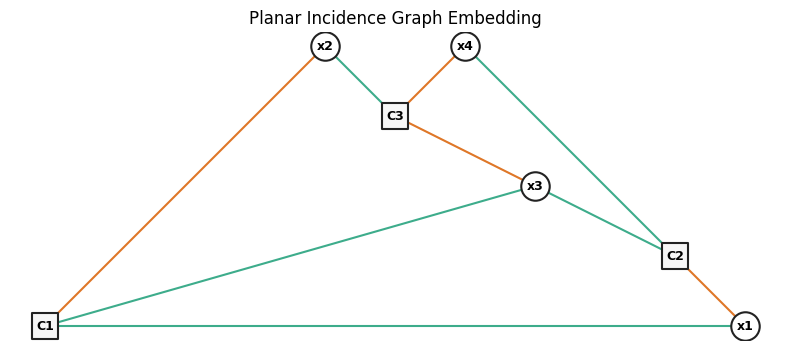

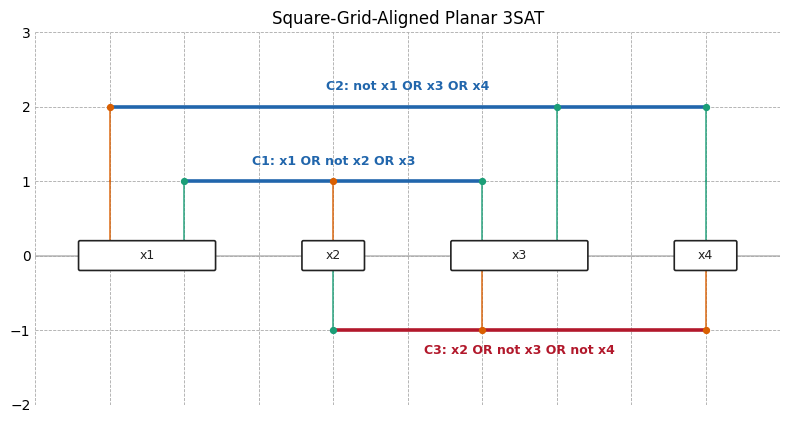

In [142]:
example_formula = CNF(
    from_clauses=[
        [1, -2, 3],
        [-1, 3, 4],
        [2, -3, -4],
    ]
)

incidence_graph, planar_embedding = validate_planar_formula(example_formula)
summarize_embedding(incidence_graph, planar_embedding)
draw_planar_embedding(incidence_graph, planar_embedding)

example_graph = draw_formula_sga(example_formula)

## Counterexample Candidate

This planar 3SAT instance has a planar incidence graph, but no variable-cycle
embedding was found after checking every cyclic variable order. Since a
rectilinear variable-row drawing would imply such a cycle, this is a concrete
obstruction for the unrestricted Planar 3SAT setting.

Incidence graph: 14 nodes, 20 edges

Rotation system, clockwise neighbors at each node:
  C1: ['x1', 'x4', 'x5']
  C2: ['x1', 'x4', 'x2']
  C3: ['x4', 'x3', 'x2']
  C4: ['x3', 'x4', 'x1']
  C5: ['x2', 'x4']
  C6: ['x3', 'x4', 'x7']
  C7: ['x2', 'x4', 'x6']
  x1: ['C1', 'C2', 'C4']
  x2: ['C3', 'C2', 'C5', 'C7']
  x3: ['C3', 'C6', 'C4']
  x4: ['C2', 'C1', 'C4', 'C6', 'C3', 'C7', 'C5']
  x5: ['C1']
  x6: ['C7']
  x7: ['C6']

Faces:
  F1: ['C1', 'x1', 'C4', 'x4']
  F2: ['C1', 'x4', 'C2', 'x1', 'C1', 'x5']
  F3: ['x1', 'C2', 'x2', 'C3', 'x3', 'C4']
  F4: ['x4', 'C4', 'x3', 'C6', 'x7', 'C6']
  F5: ['x4', 'C6', 'x3', 'C3']
  F6: ['x4', 'C3', 'x2', 'C7', 'x6', 'C7']
  F7: ['x4', 'C7', 'x2', 'C5']
  F8: ['x4', 'C5', 'x2', 'C2']
Planar embedding positions:
  C1: (-4.187, -1.451)
  C2: (8.000, -2.611)
  C3: (-1.285, 2.031)
  C4: (-3.606, -0.290)
  C5: (5.098, -0.290)
  C6: (-1.285, 1.451)
  C7: (4.518, 0.290)
  x1: (-5.927, -2.611)
  x2: (1.036, 4.352)
  x3: (-3.026, 0.290)
  x4: (2.197, -0.870)

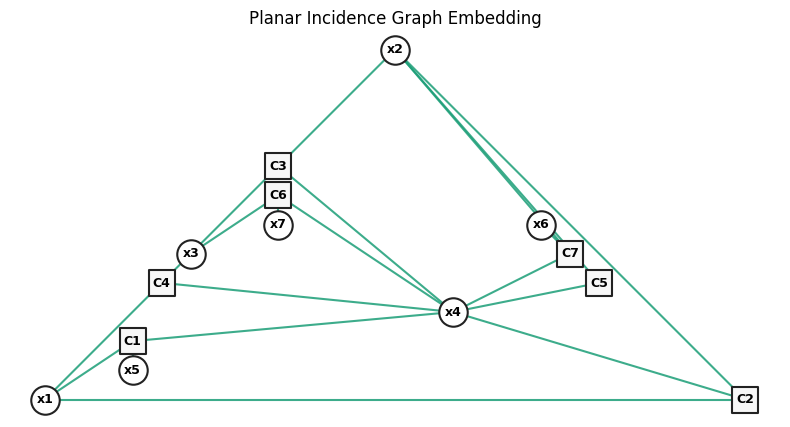

In [145]:
counterexample_formula = CNF(
    from_clauses=[
        [1, 4, 5],
        [1, 2, 4],
        [2, 3, 4],
        [1, 3, 4],
        [2, 4],
        [3, 4, 7],
        [2, 4, 6],
    ]
)

counterexample_graph, counterexample_embedding = validate_planar_formula(
    counterexample_formula
)
summarize_embedding(counterexample_graph, counterexample_embedding)
draw_planar_embedding(counterexample_graph, counterexample_embedding, 69.0)

has_cycle, cycle_order, _cycle_embedding = find_variable_cycle_embedding(
    counterexample_formula,
    max_variables=7
)
print("Variable-cycle embedding exists:", has_cycle)
print("Variable-cycle order:", cycle_order)

try:
    draw_formula_sga(counterexample_formula, max_variable_order_search=7)
except ValueError as error:
    print("SGA conversion failed as expected:")
    print(error)